In [1]:
import pandas as pd

In [2]:
file="metadata.csv"
df = pd.read_csv(file)
df.head()

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,benign_malignant,concomitant_biopsy,diagnosis,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_confirm_type,image_type,lesion_id,melanocytic,sex
0,ISIC_0053453,Hospital Clínic de Barcelona,CC-BY-NC,60.0,anterior torso,NaN,benign,True,nevus,Benign,Benign melanocytic proliferations,Nevus,histopathology,dermoscopic,IL_0433332,True,male
1,ISIC_0053454,Hospital Clínic de Barcelona,CC-BY-NC,55.0,anterior torso,NaN,malignant,True,melanoma,Malignant,Malignant melanocytic proliferations (Melanoma),"Melanoma, NOS",histopathology,dermoscopic,IL_8314504,True,male
2,ISIC_0053455,Hospital Clínic de Barcelona,CC-BY-NC,50.0,lower extremity,NaN,NaN,True,other,NaN,NaN,NaN,histopathology,dermoscopic,IL_8065011,NaN,male
3,ISIC_0053456,Hospital Clínic de Barcelona,CC-BY-NC,50.0,anterior torso,NaN,malignant,True,melanoma,Malignant,Malignant melanocytic proliferations (Melanoma),"Melanoma, NOS",histopathology,dermoscopic,IL_5496448,True,female
4,ISIC_0053457,Hospital Clínic de Barcelona,CC-BY-NC,85.0,head/neck,NaN,NaN,True,squamous cell carcinoma,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, NOS",histopathology,dermoscopic,IL_7128083,False,male


In [3]:
summary = {
    "Numero de filas" : df.shape[0],
    "Numero de de colummnas" : df.shape[1],
    "Columnas categóricas" : df.select_dtypes(include = ['object']).columns.tolist(),
    "Columnas numèricas" :  df.select_dtypes(include=['number']).columns.tolist()
}
summary

{'Numero de filas': 18946,
 'Numero de de colummnas': 17,
 'Columnas categóricas': ['isic_id',
  'attribution',
  'copyright_license',
  'anatom_site_general',
  'anatom_site_special',
  'benign_malignant',
  'diagnosis',
  'diagnosis_1',
  'diagnosis_2',
  'diagnosis_3',
  'diagnosis_confirm_type',
  'image_type',
  'lesion_id',
  'melanocytic',
  'sex'],
 'Columnas numèricas': ['age_approx']}

In [4]:
unique_values = df.nunique()
missing_values = df.isnull().sum()
summary_df = pd.DataFrame({
    "Valores Nulos" : missing_values,
    "Valores Únicos" : unique_values
}).sort_values(by="Valores Nulos", ascending=False)
summary_df

,Valores Nulos,Valores Únicos
anatom_site_special,18177,2
benign_malignant,9296,2
diagnosis_confirm_type,3506,2
diagnosis_3,1307,10
melanocytic,1156,2
diagnosis_1,1156,3
diagnosis_2,1156,8
anatom_site_general,297,6
age_approx,121,18
sex,117,2


In [5]:
import matplotlib.pyplot as plt
#numeros de datos por cada clase en variable
image_type_counts = df['diagnosis'].value_counts(dropna=False)
image_type_counts

diagnosis
nevus                      5647
melanoma                   4003
basal cell carcinoma       3676
seborrheic keratosis       1268
other                      1156
actinic keratosis          1088
melanoma metastasis         633
squamous cell carcinoma     559
scar                        314
solar lentigo               283
dermatofibroma              168
vascular lesion             151
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

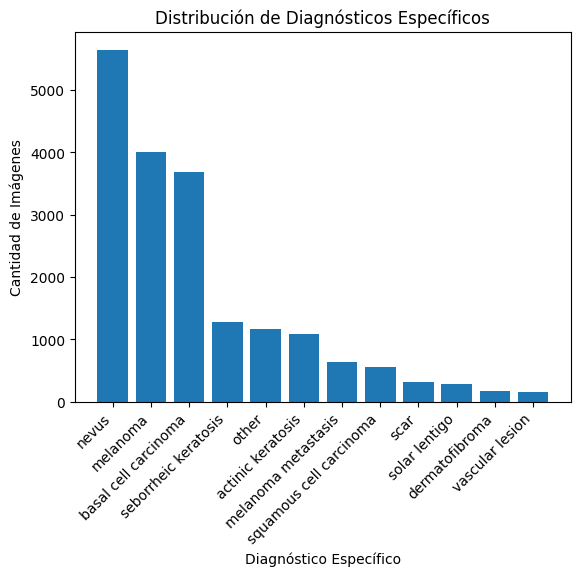

In [6]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Diagnósticos Específicos")
plt.xlabel("Diagnóstico Específico")
plt.ylabel("Cantidad de Imágenes")


In [7]:
#numeros de datos por cada clase en variable
image_type_counts = df['diagnosis_1'].value_counts(dropna=False)
image_type_counts

diagnosis_1
Malignant        8871
Benign           7831
NaN              1156
Indeterminate    1088
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

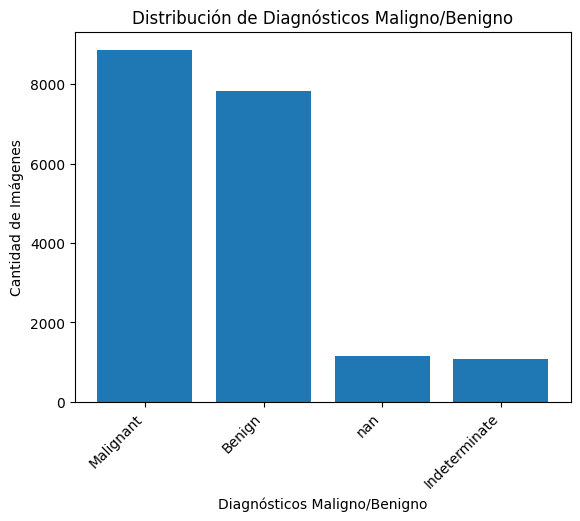

In [8]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Diagnósticos Maligno/Benigno')
plt.xlabel('Diagnósticos Maligno/Benigno')
plt.ylabel('Cantidad de Imágenes')

In [9]:
duplicados = df.duplicated(subset=['isic_id']).sum()
print("Duplicados por isic_id: ",duplicados)

Duplicados por isic_id:  0


In [10]:
df_clean = df[df['diagnosis'] !="other"].copy()

In [11]:
from tools.remove_data import remove
data_clean = remove(
    img_dir="archive-2",
    out_dir="archive-2_clean",
    df = df_clean,
    col = "isic_id"
)

Copiando imágenes filtradas: 100%|██████████| 17790/17790 [03:08<00:00, 94.27it/s] 

Filas df_clean: 17790
Imágenes copiadas: 17790
No encontradas: 0
Carpeta salida: E:\Pipeline\Pipeline_Derma\archive-2_clean


In [12]:
image_type_counts = df_clean['diagnosis'].value_counts(dropna=False)
image_type_counts

diagnosis
nevus                      5647
melanoma                   4003
basal cell carcinoma       3676
seborrheic keratosis       1268
actinic keratosis          1088
melanoma metastasis         633
squamous cell carcinoma     559
scar                        314
solar lentigo               283
dermatofibroma              168
vascular lesion             151
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

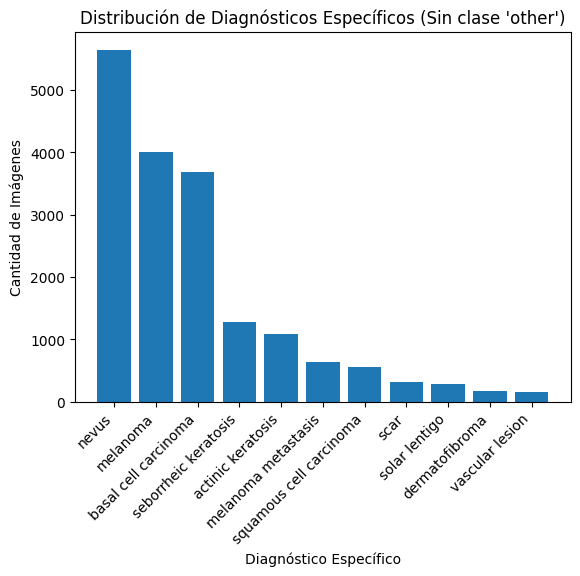

In [13]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Diagnósticos Específicos (Sin clase 'other')")
plt.xlabel("Diagnóstico Específico")
plt.ylabel("Cantidad de Imágenes")

In [14]:
image_type_counts = df_clean['diagnosis_1'].value_counts(dropna=False)
image_type_counts

diagnosis_1
Malignant        8871
Benign           7831
Indeterminate    1088
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

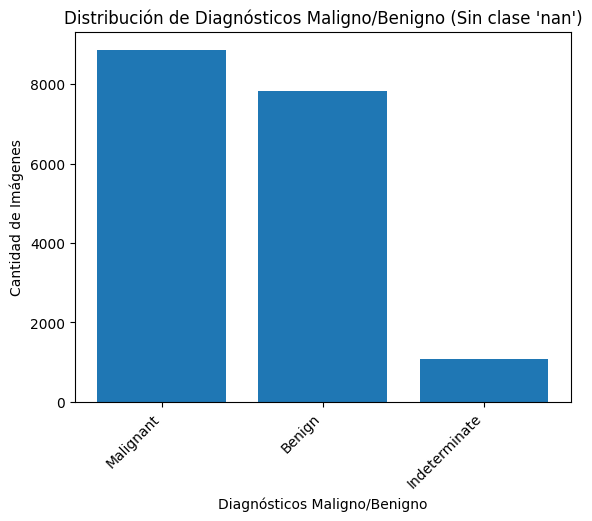

In [15]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Diagnósticos Maligno/Benigno (Sin clase 'nan')")
plt.xlabel("Diagnósticos Maligno/Benigno")
plt.ylabel("Cantidad de Imágenes")

In [16]:
from tools.duplicados import export_images_without_duplicates
stats = export_images_without_duplicates(
    img_dir="archive-2_clean",
    out_dir="archive-2_no_dupes",
    exts=(".jpg",),
    phash_threshold=None,          #rápido
    use_sha256=True,            #recomendado
    preserve_structure=False,
    dry_run = False, 
    review_dir="review_dupes"   #rep + duplicadas por grupo
)

Copiando (final): 100%|██████████| 17743/17743 [00:43<00:00, 407.81it/s]


REPORTE DETALLADO (Archivo Conservado <--- Duplicados Eliminados)
[KEEP] ISIC_0053738.jpg               <--- [DEL] ISIC_0073198.jpg
[KEEP] ISIC_0053812.jpg               <--- [DEL] ISIC_0071101.jpg
[KEEP] ISIC_0054023.jpg               <--- [DEL] ISIC_0064545.jpg
[KEEP] ISIC_0054074.jpg               <--- [DEL] ISIC_0071589.jpg
[KEEP] ISIC_0054075.jpg               <--- [DEL] ISIC_0061861.jpg
[KEEP] ISIC_0054113.jpg               <--- [DEL] ISIC_0070345.jpg
[KEEP] ISIC_0054118.jpg               <--- [DEL] ISIC_0056756.jpg
[KEEP] ISIC_0054334.jpg               <--- [DEL] ISIC_0056130.jpg
[KEEP] ISIC_0054763.jpg               <--- [DEL] ISIC_0054802.jpg
[KEEP] ISIC_0054792.jpg               <--- [DEL] ISIC_0072272.jpg
[KEEP] ISIC_0054911.jpg               <--- [DEL] ISIC_0062368.jpg
[KEEP] ISIC_0054986.jpg               <--- [DEL] ISIC_0067341.jpg
[KEEP] ISIC_0055643.jpg               <--- [DEL] ISIC_0065417.jpg
[KEEP] ISIC_0056728.jpg               <--- [DEL] ISIC_0068343.jpg
[KEEP] IS

In [17]:
df_clean[df_clean['isic_id'] == "ISIC_0067718" ]

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,benign_malignant,concomitant_biopsy,diagnosis,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_confirm_type,image_type,lesion_id,melanocytic,sex
13646,ISIC_0067718,Hospital Clínic de Barcelona,CC-BY-NC,50.0,anterior torso,NaN,benign,True,nevus,Benign,Benign melanocytic proliferations,Nevus,histopathology,dermoscopic,IL_4116999,True,male


In [18]:

df_clean[df_clean['isic_id'] == "ISIC_0064289" ]

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,benign_malignant,concomitant_biopsy,diagnosis,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_confirm_type,image_type,lesion_id,melanocytic,sex
10357,ISIC_0064289,Hospital Clínic de Barcelona,CC-BY-NC,50.0,anterior torso,NaN,benign,True,nevus,Benign,Benign melanocytic proliferations,Nevus,histopathology,dermoscopic,IL_4116999,True,male


In [19]:
df_no_dupes = df_clean.copy()
from tools.sincronizar import sincronizar_
df_no_dupes = sincronizar_(df_no_dupes,img_dir='archive-2_no_dupes',col='isic_id',extension='.jpg')

--- Reporte de Sincronización ---
Filas originales: 17790
Filas conservadas: 17743
Filas eliminadas (no encontradas en disco): 47
---------------------------------


In [20]:
len(df_no_dupes)

17743

In [21]:
unique_values = df_no_dupes.nunique()
missing_values = df_no_dupes.isnull().sum()
summary_df = pd.DataFrame({
    "Valores Nulos" : missing_values,
    "Valores Únicos" : unique_values
}).sort_values(by="Valores Nulos", ascending=False)
summary_df

,Valores Nulos,Valores Únicos
anatom_site_special,17069,2
benign_malignant,8111,2
diagnosis_confirm_type,3271,2
anatom_site_general,257,6
diagnosis_3,151,10
age_approx,114,18
sex,110,2
melanocytic,0,2
lesion_id,0,5076
image_type,0,1


In [22]:
image_type_counts = df_no_dupes['diagnosis'].value_counts(dropna=False)
image_type_counts

diagnosis
nevus                      5638
melanoma                   3994
basal cell carcinoma       3669
seborrheic keratosis       1256
actinic keratosis          1080
melanoma metastasis         633
squamous cell carcinoma     559
scar                        314
solar lentigo               281
dermatofibroma              168
vascular lesion             151
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

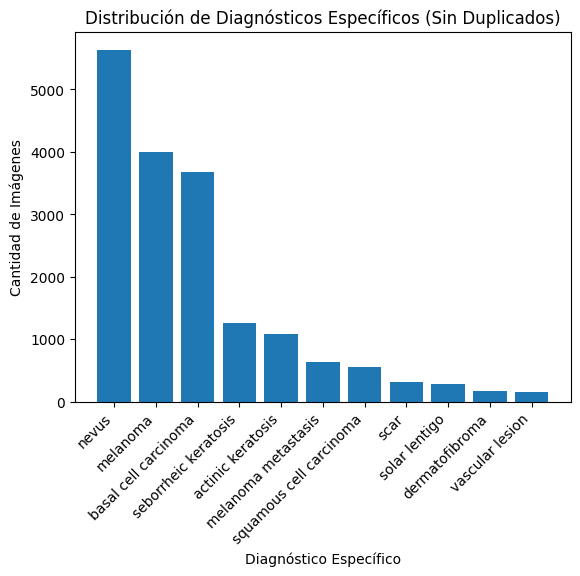

In [23]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Diagnósticos Específicos (Sin Duplicados)")
plt.xlabel("Diagnóstico Específico")
plt.ylabel("Cantidad de Imágenes")

In [24]:
image_type_counts = df_no_dupes['diagnosis_1'].value_counts(dropna=False)
image_type_counts

diagnosis_1
Malignant        8855
Benign           7808
Indeterminate    1080
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

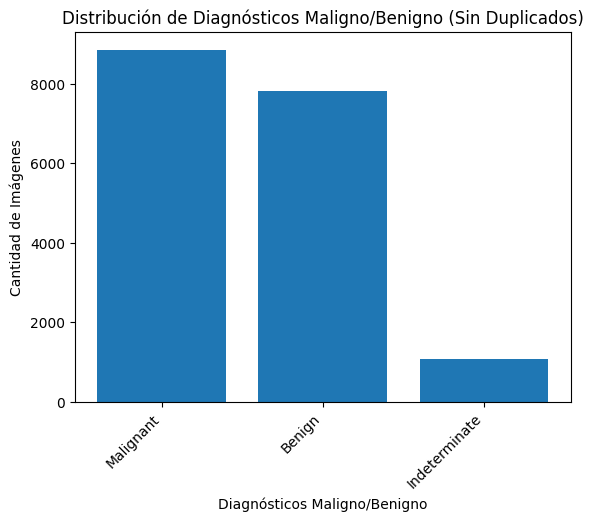

In [25]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Diagnósticos Maligno/Benigno (Sin Duplicados)")
plt.xlabel("Diagnósticos Maligno/Benigno")
plt.ylabel("Cantidad de Imágenes")

In [26]:
# Mapeo para la Cabeza 1 (General)
map_general = {
    'Malignant': 0,
    'Benign': 1,
    'Indeterminate': -1
    }

# Mapeo para la Cabeza 2 (Específico)
map_especifico = {
    'melanoma': 0,
    'basal cell carcinoma': 1,
    'squamous cell carcinoma': 2,
    'melanoma metastasis': 3,
    'nevus': 4,
    'seborrheic keratosis': 5,
    'solar lentigo': 6,
    'dermatofibroma': 7, 
    'vascular lesion': 8,
    'scar': 9,
    'actinic keratosis': 10
}

df_no_dupes['diagnosis_1_label'] = df_no_dupes['diagnosis_1'].map(map_general)
df_no_dupes['diagnosis_label'] = df_no_dupes['diagnosis'].map(map_especifico)

In [27]:
from sklearn.model_selection import GroupShuffleSplit

seed = 42
df_no_dupes = df_no_dupes.sort_values(by='isic_id').reset_index(drop=True)

#70% para el entrenamiento 
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=seed)
train_idx, temp_idx = next(gss.split(df_no_dupes, groups=df_no_dupes['lesion_id']))

train_df = df_no_dupes.iloc[train_idx].copy()
temp_df = df_no_dupes.iloc[temp_idx].copy()

#30% restantes lo dividimos a la mitad 

gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.5,random_state=seed)
val_idx, test_idx = next(gss_val_test.split(temp_df, groups=temp_df['lesion_id']))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

In [28]:
print('train:', len(train_df))
print('Validacion:', len(val_df))
print('test:', len(test_df))

train: 12466
Validacion: 2628
test: 2649


In [29]:
image_type_counts = train_df['diagnosis_1'].value_counts(dropna=False)
image_type_counts

diagnosis_1
Malignant        6189
Benign           5520
Indeterminate     757
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

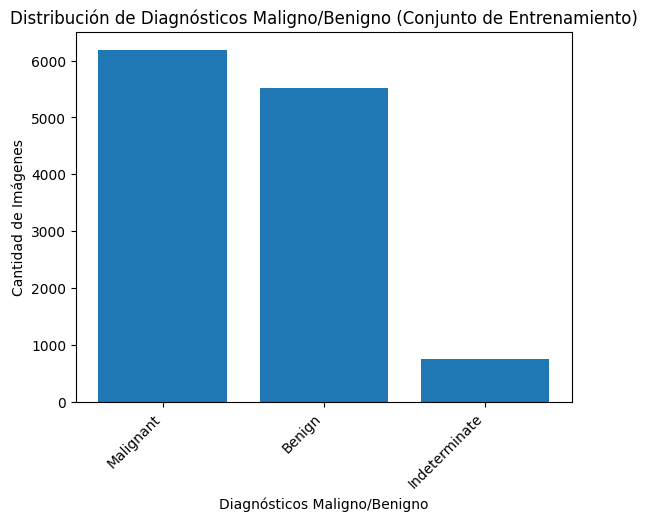

In [30]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Diagnósticos Maligno/Benigno (Conjunto de Entrenamiento)")
plt.xlabel("Diagnósticos Maligno/Benigno")
plt.ylabel("Cantidad de Imágenes")

In [31]:
image_type_counts = train_df['diagnosis'].value_counts(dropna=False)
image_type_counts

diagnosis
nevus                      3969
melanoma                   2792
basal cell carcinoma       2585
seborrheic keratosis        876
actinic keratosis           757
melanoma metastasis         444
squamous cell carcinoma     368
scar                        239
solar lentigo               233
dermatofibroma              119
vascular lesion              84
Name: count, dtype: int64

Text(0, 0.5, 'Cantidad de Imágenes')

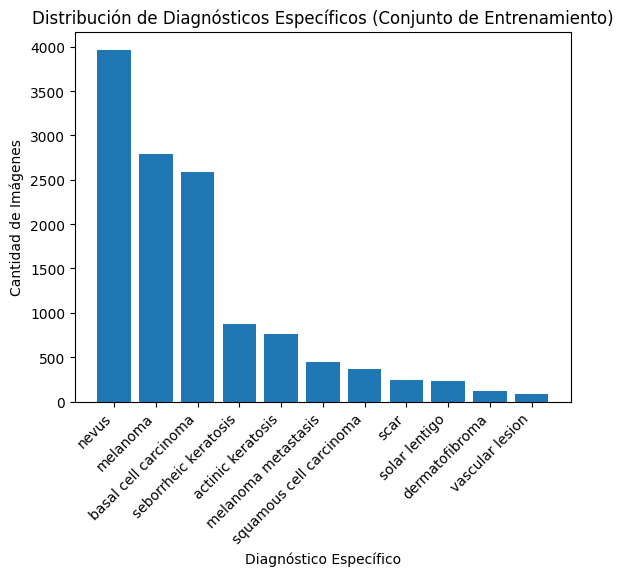

In [32]:
plt.bar(image_type_counts.index.astype(str), image_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de Diagnósticos Específicos (Conjunto de Entrenamiento)")
plt.xlabel("Diagnóstico Específico")
plt.ylabel("Cantidad de Imágenes")

In [33]:
from tools.nose import organizar_dataset
from tools.labels_json import labels_json
organizar_dataset(train_df,img_dir='archive-2_no_dupes',dst_path='train',col_id='isic_id')
organizar_dataset(val_df,img_dir='archive-2_no_dupes',dst_path='validacion',col_id='isic_id')
organizar_dataset(test_df,img_dir='archive-2_no_dupes',dst_path='test',col_id='isic_id')
labels_json(train_df,col_id='isic_id',label='diagnosis_label',out_dir='train')
labels_json(val_df,col_id='isic_id',label='diagnosis_label',out_dir='validacion')
labels_json(test_df,col_id='isic_id',label='diagnosis_label',out_dir='test')
labels_json(train_df, col_id='isic_id', label='diagnosis_1_label', out_dir='train', name='dataset_binary.json')
labels_json(val_df, col_id='isic_id', label='diagnosis_1_label', out_dir='validacion', name='dataset_binary.json')
labels_json(test_df, col_id='isic_id', label='diagnosis_1_label', out_dir='test', name='dataset_binary.json')


Organizando set de train...


100%|██████████| 12466/12466 [02:37<00:00, 78.99it/s] 


imagenes copiadas correctamente
Organizando set de validacion...


100%|██████████| 2628/2628 [00:25<00:00, 101.59it/s]


imagenes copiadas correctamente
Organizando set de test...


100%|██████████| 2649/2649 [00:26<00:00, 100.40it/s]


imagenes copiadas correctamente
Archivo creado.
Archivo creado.
Archivo creado.
Archivo creado.
Archivo creado.
Archivo creado.
